In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer as imp


In [2]:
data = pd.read_csv("smartcart_customers.csv")
data.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
data.info

<bound method DataFrame.info of          ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
0      5524        1957  Graduation         Single  58138.0        0   
1      2174        1954  Graduation         Single  46344.0        1   
2      4141        1965  Graduation       Together  71613.0        0   
3      6182        1984  Graduation       Together  26646.0        1   
4      5324        1981         PhD        Married  58293.0        1   
...     ...         ...         ...            ...      ...      ...   
2235  10870        1967  Graduation        Married  61223.0        0   
2236   4001        1946         PhD       Together  64014.0        2   
2237   7270        1981  Graduation       Divorced  56981.0        0   
2238   8235        1956      Master       Together  69245.0        0   
2239   9405        1954         PhD        Married  52869.0        1   

      Teenhome Dt_Customer  Recency  MntWines  ...  MntFishProducts  \
0            0  04-09-2012      

# First We Want To Remove Null Values 

In [5]:
imputer = imp(strategy = 'median')
data[["Income"]] = imputer.fit_transform(data[["Income"]] )

In [6]:
data.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

# Now all the values are complete in out data so then if there is no missing values 
# we can now move to Feature Selection and Feature Engineering

In [7]:
#  we can create so much meaningful  features from our data  
#  like from "Year_Birth" we can create Age of our Customer and then we can remove Year_Birth
#  from spending data we can create total spendings and completely remove all unnecessary features
# this helps a lot in dimension reduction and accuracy maintainance for smart clustering

In [8]:
 data["Age"] = 2026 - data["Year_Birth"]

In [9]:
data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,118,247,2,9,3,4,5,0,0,59
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,0,8,7,8,2,5,7,0,0,80
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,12,24,1,2,3,13,6,0,0,45
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,30,61,2,6,5,10,3,0,0,70


In [10]:
data["TotalSpendings"] =  data["MntGoldProds"] + data["MntSweetProducts"]+data["MntMeatProducts"]+data["MntFishProducts"]+data["MntFruits"]+ data["MntWines"]

In [11]:
data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,TotalSpendings
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,3,8,10,4,7,0,1,69,1617
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,6,2,1,1,2,5,0,0,72,27
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,42,1,8,2,10,4,0,0,61,776
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,5,2,2,0,4,6,0,0,42,53
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,15,5,5,3,6,5,0,0,45,422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,247,2,9,3,4,5,0,0,59,1341
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,8,7,8,2,5,7,0,0,80,444
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,24,1,2,3,13,6,0,0,45,1241
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,61,2,6,5,10,3,0,0,70,843


In [12]:
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"] , dayfirst = True)
# we can use today's date but for consistency in model we use maximum value or we can say least recent date
reference_date = data["Dt_Customer"].max()
data["tenure_days"] = (reference_date - data["Dt_Customer"]).dt.days

In [13]:
reference_date

Timestamp('2014-06-29 00:00:00')

In [14]:
data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,TotalSpendings,tenure_days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,69,1617,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,72,27,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,61,776,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,42,53,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,45,422,161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,2,9,3,4,5,0,0,59,1341,381
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,7,8,2,5,7,0,0,80,444,19
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,1,2,3,13,6,0,0,45,1241,155
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,2,6,5,10,3,0,0,70,843,156


In [15]:
data["total_childs"] = data["Kidhome"] + data["Teenhome"]

In [16]:
data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,TotalSpendings,tenure_days,total_childs
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,1617,663,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,27,113,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,776,312,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,53,139,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,422,161,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,9,3,4,5,0,0,59,1341,381,1
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,8,2,5,7,0,0,80,444,19,3
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,2,3,13,6,0,0,45,1241,155,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,6,5,10,3,0,0,70,843,156,1


In [17]:
data["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [18]:
data["Education"] = data["Education"].replace({"Graduation" : "Graduate" , "PhD" : "PostGraduate" , "Master" : "PostGraduate"
                                               , "2n Cycle" : "UnderGraduate" , "Basic" : "UnderGraduate" })
                                               

In [19]:
data["Education"].value_counts()


Education
Graduate         1127
PostGraduate      856
UnderGraduate     257
Name: count, dtype: int64

In [20]:
data["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [21]:
data["Marital_Status"] = data["Marital_Status"].replace({
    "Married" : "Partner",
    "Together" : "Partner",
    "Single" : "Single",
    "Divorced" : "Single",
    "Widow" : "Single",
    "Alone" : "Single",
    "Absurd" : "Single",
    "YOLO" : "Single"
})

In [22]:
data["Marital_Status"].value_counts()

Marital_Status
Partner    1444
Single      796
Name: count, dtype: int64

# Now we are Dropping Columns to reduce dimensions

In [23]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'TotalSpendings', 'tenure_days',
       'total_childs'],
      dtype='object')

In [24]:
dropping_columns = ["ID" , "Year_Birth" , "Kidhome" ,"Teenhome" , "Dt_Customer",
                    "MntWines" , "MntFruits" , "MntMeatProducts" , "MntFishProducts",
                    "MntSweetProducts" , "MntGoldProds" ]
cleaned_data = data.drop(dropping_columns , axis =1)

In [25]:
cleaned_data

,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,TotalSpendings,tenure_days,total_childs
0,Graduate,Single,58138.0,58,3,8,10,4,7,0,1,69,1617,663,0
1,Graduate,Single,46344.0,38,2,1,1,2,5,0,0,72,27,113,2
2,Graduate,Partner,71613.0,26,1,8,2,10,4,0,0,61,776,312,0
3,Graduate,Partner,26646.0,26,2,2,0,4,6,0,0,42,53,139,1
4,PostGraduate,Partner,58293.0,94,5,5,3,6,5,0,0,45,422,161,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,Graduate,Partner,61223.0,46,2,9,3,4,5,0,0,59,1341,381,1
2236,PostGraduate,Partner,64014.0,56,7,8,2,5,7,0,0,80,444,19,3
2237,Graduate,Single,56981.0,91,1,2,3,13,6,0,0,45,1241,155,0
2238,PostGraduate,Partner,69245.0,8,2,6,5,10,3,0,0,70,843,156,1


# Now we can do Outlier Detection and Removal 

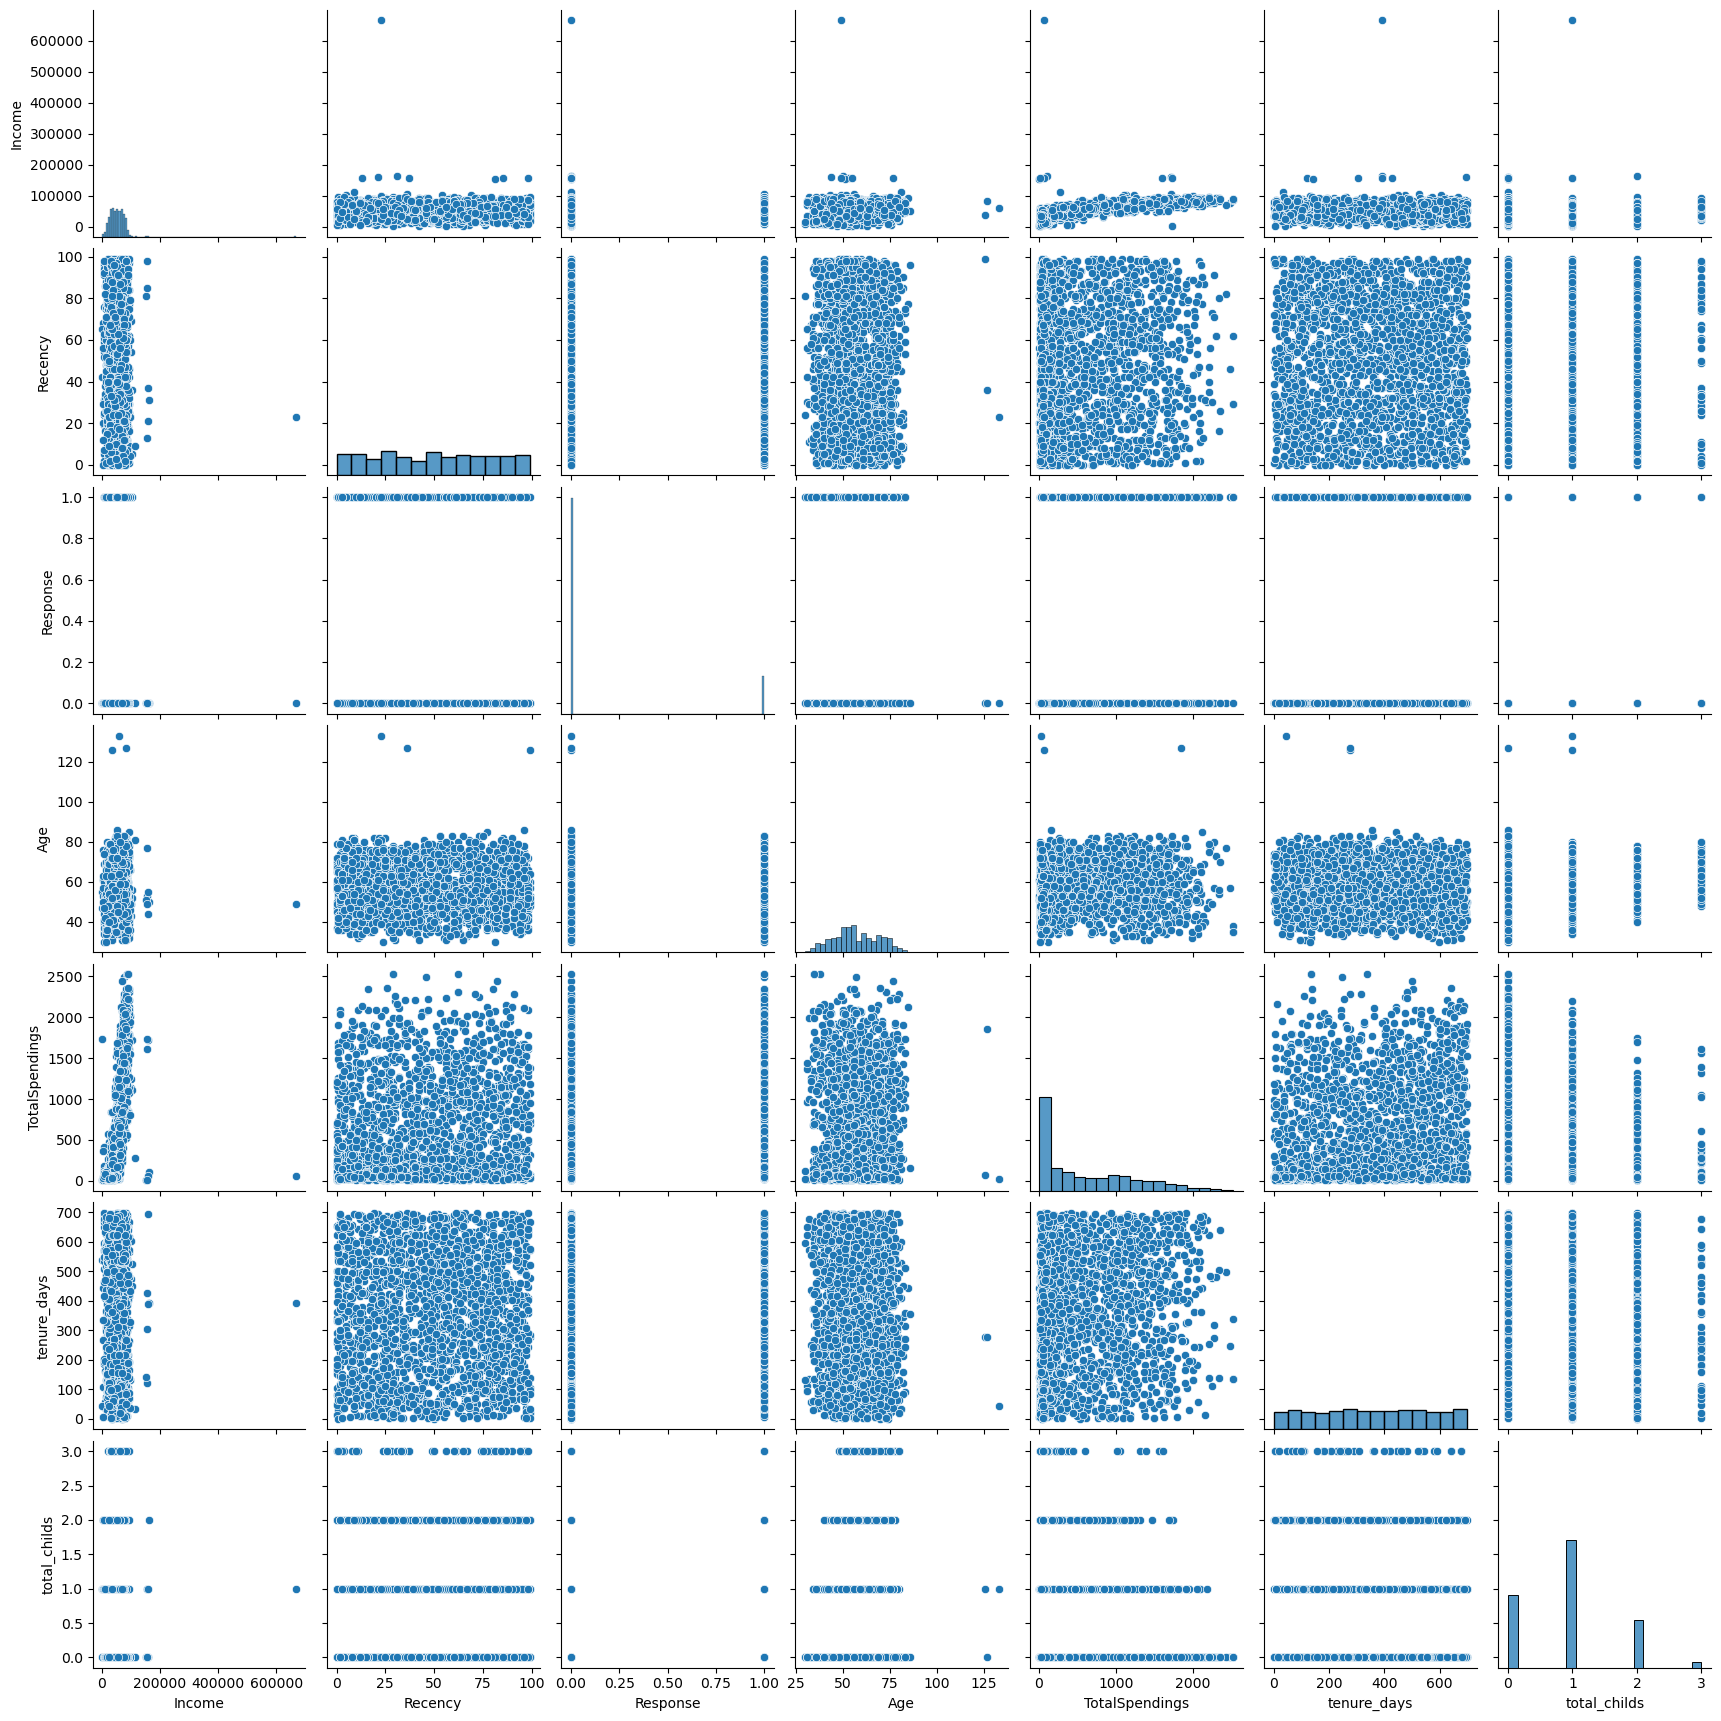

In [26]:
columns=["Income" ,"Recency" ,"Response", "Age" , "TotalSpendings" , "tenure_days" , "total_childs" ]
sns.pairplot(cleaned_data[columns])

In [27]:
cleaned_data = cleaned_data[(cleaned_data["Age"] <90)]
cleaned_data = cleaned_data[(cleaned_data["Income"] <500000)]



In [28]:
cleaned_data.shape

(2236, 15)

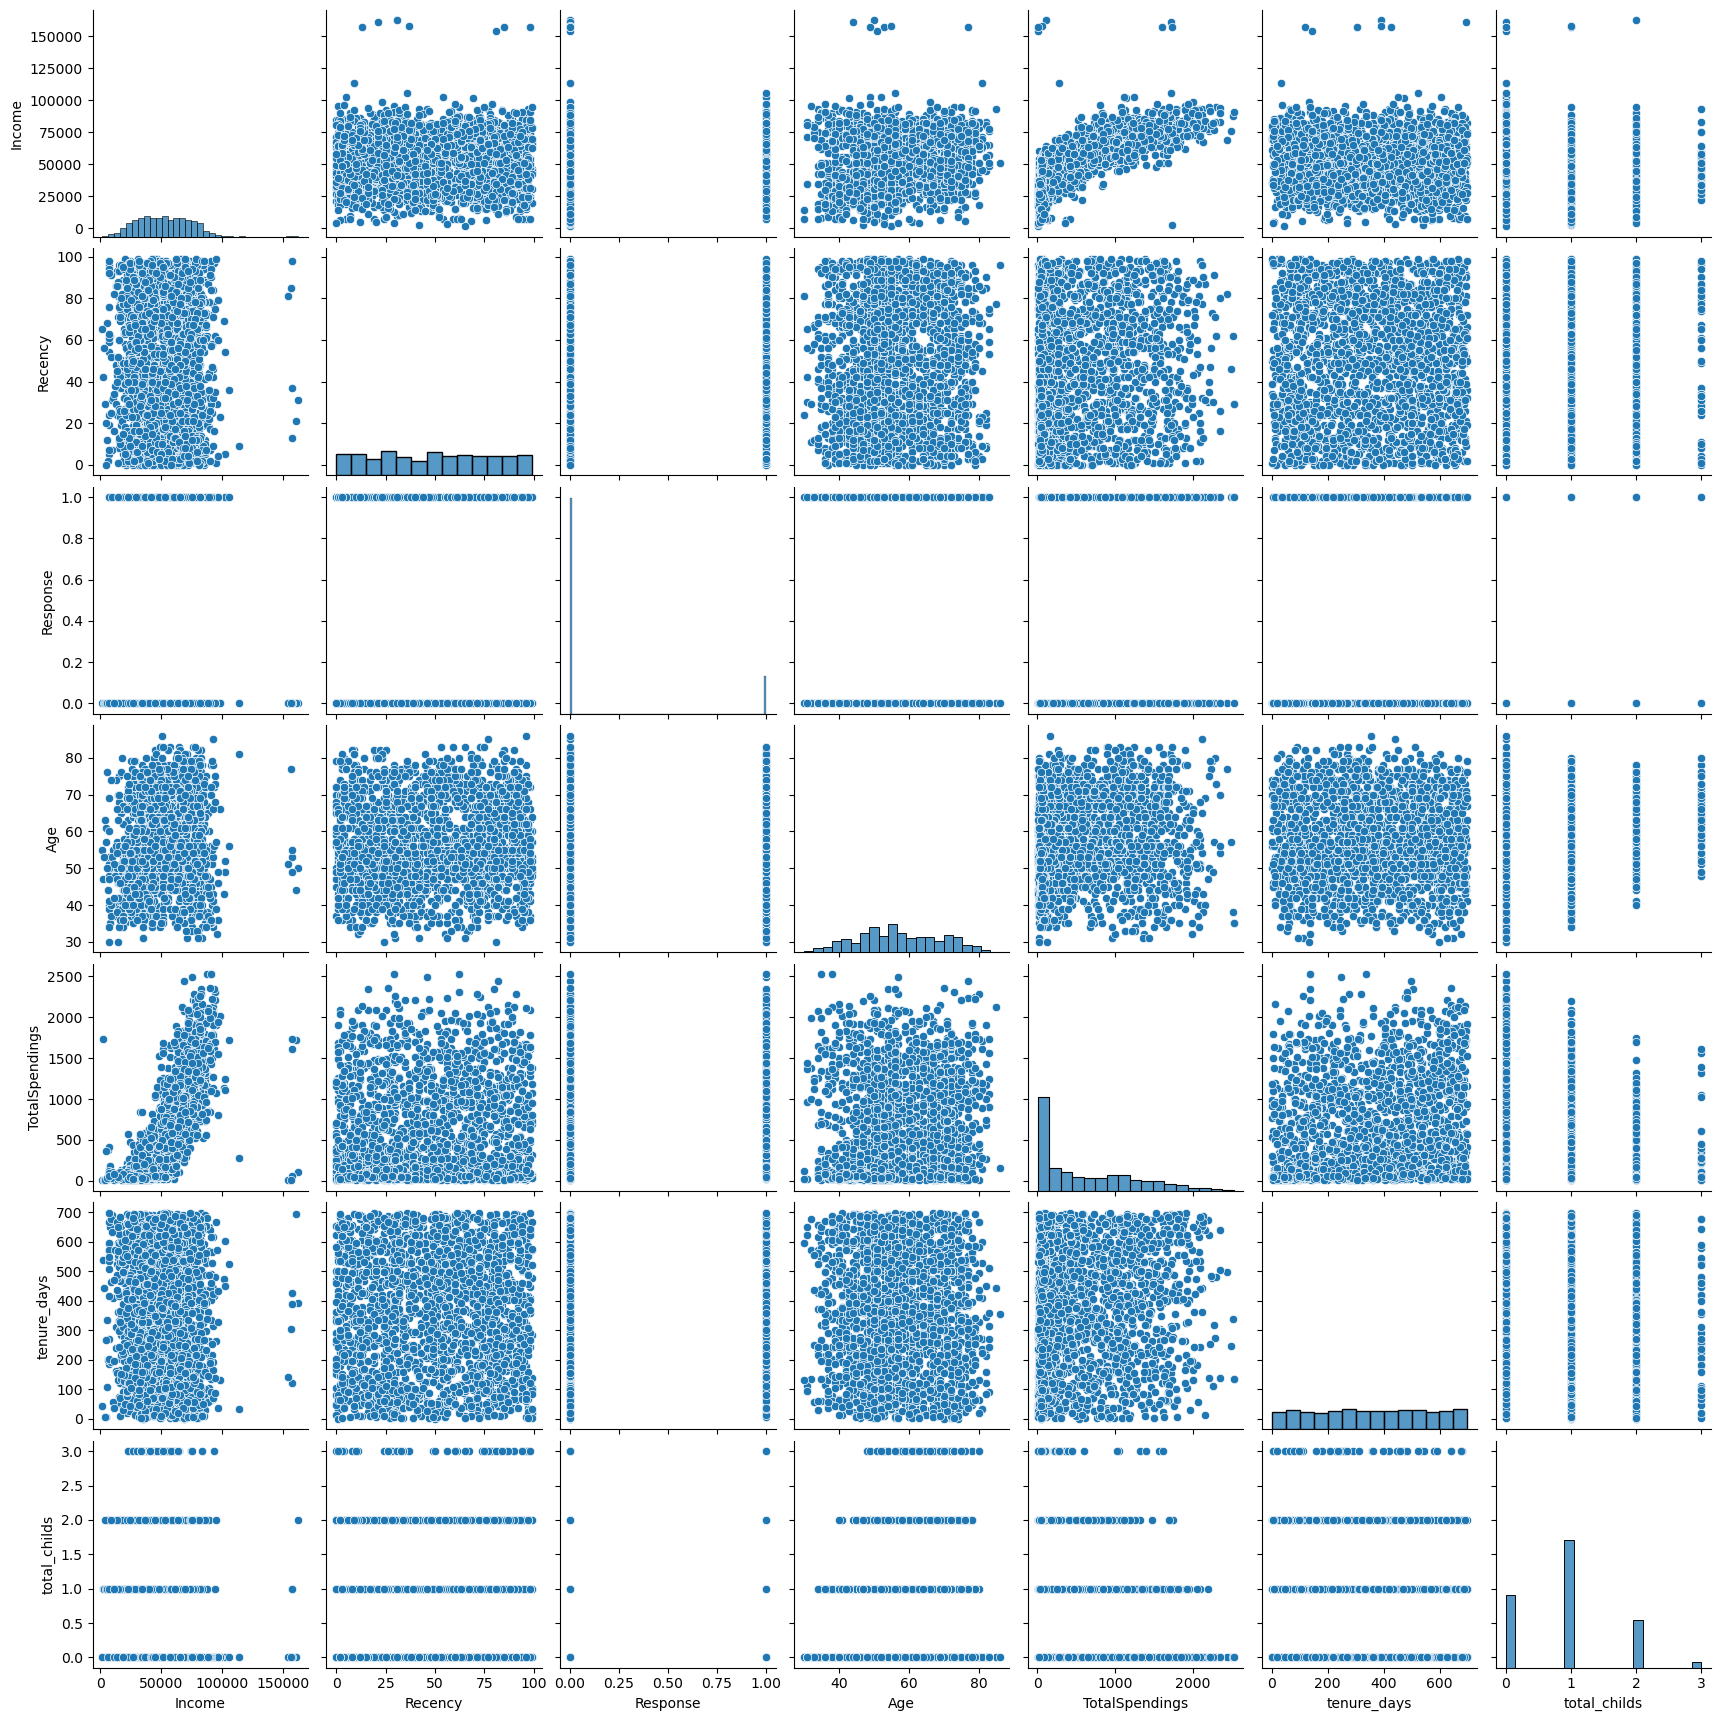

In [116]:
sns.pairplot(cleaned_data[columns])


In [30]:
corr = cleaned_data.corr(numeric_only = True)

<Axes: >

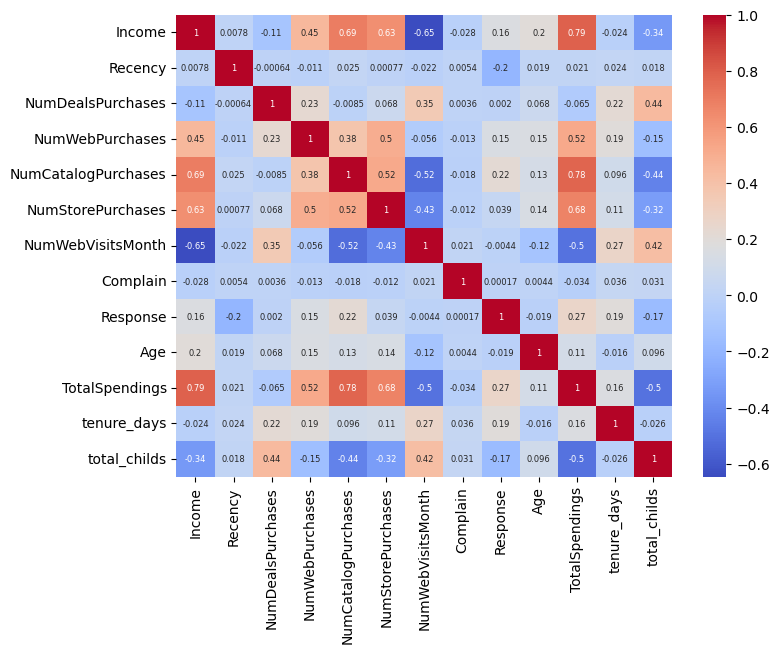

In [31]:
plt.figure(figsize = (8 , 6))
sns. heatmap(
     corr,
     annot=True,
     annot_kws={"size": 6},
     cmap="coolwarm"
)

# Now we have  our cleaned data so we can go to scale and encode our data for a better traning and better clustering

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [36]:
scaler = StandardScaler()
ohe = OneHotEncoder()
cleaned_data.head()

,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,TotalSpendings,tenure_days,total_childs
0,Graduate,Single,58138.0,58,3,8,10,4,7,0,1,69,1617,663,0
1,Graduate,Single,46344.0,38,2,1,1,2,5,0,0,72,27,113,2
2,Graduate,Partner,71613.0,26,1,8,2,10,4,0,0,61,776,312,0
3,Graduate,Partner,26646.0,26,2,2,0,4,6,0,0,42,53,139,1
4,PostGraduate,Partner,58293.0,94,5,5,3,6,5,0,0,45,422,161,1


In [42]:
cat_cols = ["Education" , "Marital_Status"]


enc_cols = ohe.fit_transform(cleaned_data[cat_cols])

enc_df = pd.DataFrame(enc_cols.toarray(), columns = ohe.get_feature_names_out(cat_cols), index=cleaned_data.index)

In [43]:
enc_df.head()

,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Marital_Status_Partner,Marital_Status_Single
0,1.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,1.0,0.0


In [55]:
enc_data = pd.concat([cleaned_data.drop(columns= cat_cols), enc_df], axis=1)
enc_data.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,TotalSpendings,tenure_days,total_childs,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Marital_Status_Partner,Marital_Status_Single
0,58138.0,58,3,8,10,4,7,0,1,69,1617,663,0,1.0,0.0,0.0,0.0,1.0
1,46344.0,38,2,1,1,2,5,0,0,72,27,113,2,1.0,0.0,0.0,0.0,1.0
2,71613.0,26,1,8,2,10,4,0,0,61,776,312,0,1.0,0.0,0.0,1.0,0.0
3,26646.0,26,2,2,0,4,6,0,0,42,53,139,1,1.0,0.0,0.0,1.0,0.0
4,58293.0,94,5,5,3,6,5,0,0,45,422,161,1,0.0,1.0,0.0,1.0,0.0


# Now our data is encoded we can now convert it into same scale using standard scaler

In [57]:
X= enc_data
X = scaler.fit_transform(X)


In [58]:
X

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
        -1.3476353 ,  1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
        -1.3476353 ,  1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
         0.74204052, -0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
        -1.3476353 ,  1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
         0.74204052, -0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
         0.74204052, -0.74204052]], shape=(2236, 18))

# Now we can visualize ouur data 

In [62]:
!pip install kneed

In [70]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 3)
X_pca = pca.fit_transform(X)
X_pca

array([[ 2.7087298 , -2.39869224,  0.19587886],
       [-1.76655338, -1.82575242, -0.85552989],
       [ 1.81995208,  1.07430148, -1.27485084],
       ...,
       [ 1.42793889, -1.81716429, -1.87941234],
       [ 1.90073104,  1.4254157 ,  1.31005531],
       [-0.96995283,  0.67250249,  2.56404824]], shape=(2236, 3))

In [71]:
from sklearn.cluster import KMeans


from kneed import KneeLocator

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans. inertia_)

knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [72]:
optimal_k

np.int64(4)

Text(0.5, 0, 'PCA3')

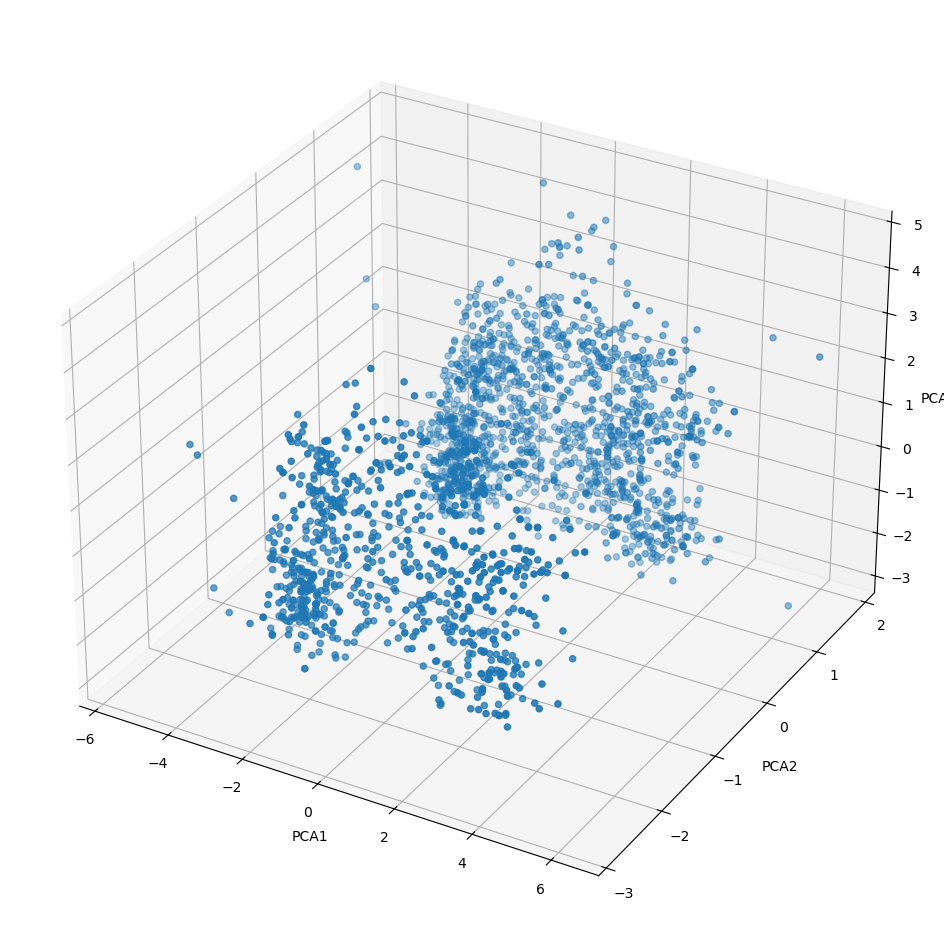

In [79]:
# Now we get 4 as a optimal k value 


fig = plt.figure(figsize =(15,12))
ax = fig.add_subplot(111, projection ="3d")
ax.scatter(X_pca[:,0] , X_pca[: ,1] , X_pca[:,2])


ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")


In [80]:
pca = PCA(n_components = 4)
X_pca2 = pca.fit_transform(X)
X_pca2

array([[ 2.7087298 , -2.39869224,  0.19587886,  2.26149695],
       [-1.76655338, -1.82575242, -0.85552989, -0.23108163],
       [ 1.81995208,  1.07430148, -1.27485084,  0.50670587],
       ...,
       [ 1.42793889, -1.81716429, -1.87941234, -0.13520063],
       [ 1.90073104,  1.4254157 ,  1.31005531, -1.21776025],
       [-0.96995283,  0.67250249,  2.56404824,  0.33619338]],
      shape=(2236, 4))

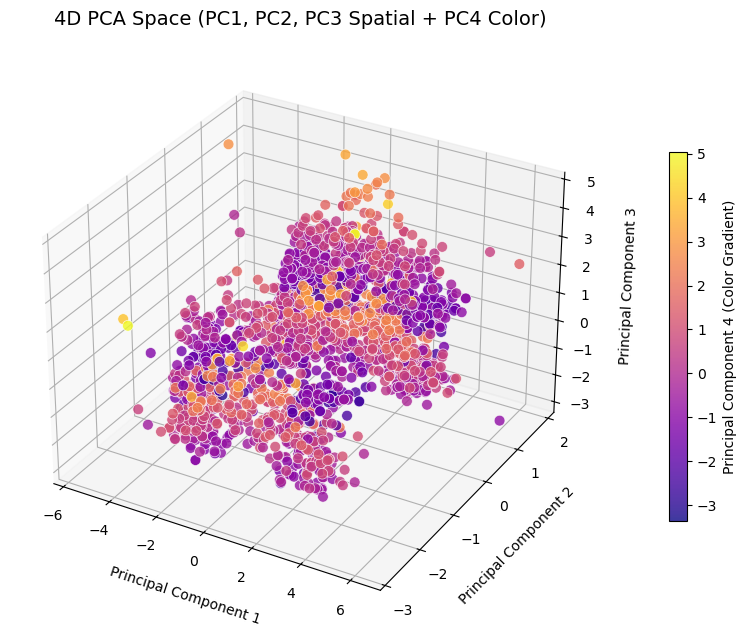

In [89]:
plt.close('all') 

# 2. Use plt.subplots to explicitly lock the figure and axes together
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': '3d'})

# 5. Map PC1, PC2, PC3 to space, and PC4 to color (cmap)
scatter = ax.scatter(
    X_pca2[:,0], X_pca2[:,1], X_pca[:,2], 
    c=X_pca2[:,3],                # 4th Dimension mapped to color
    cmap='plasma',        # High-contrast color gradient
    s=60,                 # Size of the markers
    alpha=0.8,            # Transparency to see overlapping points
    edgecolors='w',       # White edges around dots for depth clarity
    linewidth=0.5
)

# 6. Label all axes explicitly
ax.set_xlabel('Principal Component 1', fontsize=10, labelpad=10)
ax.set_ylabel('Principal Component 2', fontsize=10, labelpad=10)
ax.set_zlabel('Principal Component 3', fontsize=10, labelpad=10)
ax.set_title('4D PCA Space (PC1, PC2, PC3 Spatial + PC4 Color)', fontsize=14, pad=15)

# 7. Add a colorbar to interpret the 4th dimension (PC4)
cbar = fig.colorbar(scatter, ax=ax, pad=0.1, shrink=0.6)
cbar.set_label('Principal Component 4 (Color Gradient)', fontsize=10)

plt.show()


In [90]:
kmeans = KMeans(n_clusters = 4 , random_state = 106)

In [107]:
kmeans_labels1 = kmeans.fit_predict(X_pca)

In [108]:
kmeans_labels2 = kmeans.fit_predict(X)

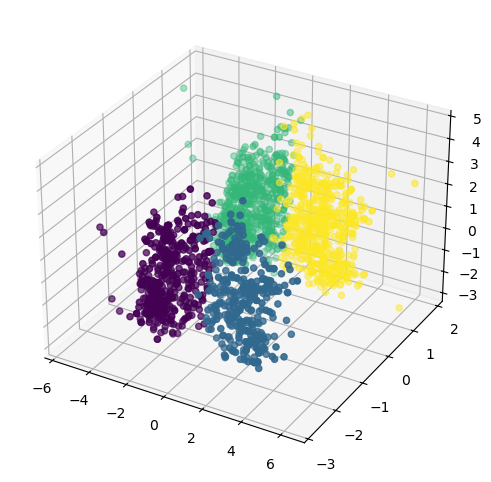

In [110]:
fig = plt.figure(figsize =(8,6))
ax = fig.add_subplot(111, projection ="3d")
ax.scatter(X_pca[:,0] , X_pca[: ,1] , X_pca[:,2] , c= kmeans_labels1)

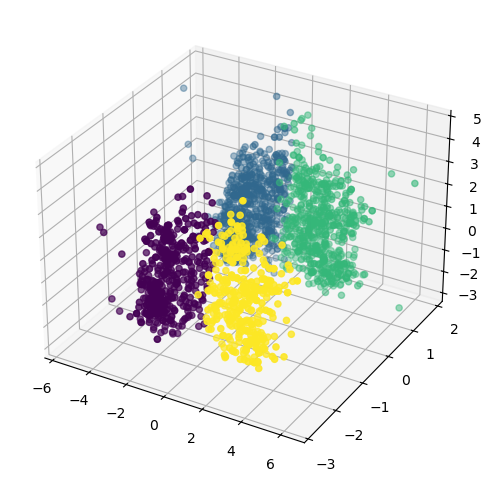

In [111]:
fig = plt.figure(figsize =(8,6))
ax = fig.add_subplot(111, projection ="3d")
ax.scatter(X_pca[:,0] , X_pca[: ,1] , X_pca[:,2] , c= kmeans_labels2)

In [98]:
#  our normal scaled data without Pca gives better result 

In [117]:
from sklearn.cluster import AgglomerativeClustering

cls = AgglomerativeClustering(n_clusters=4)
agglo_labels1 = cls.fit_predict(X_pca)



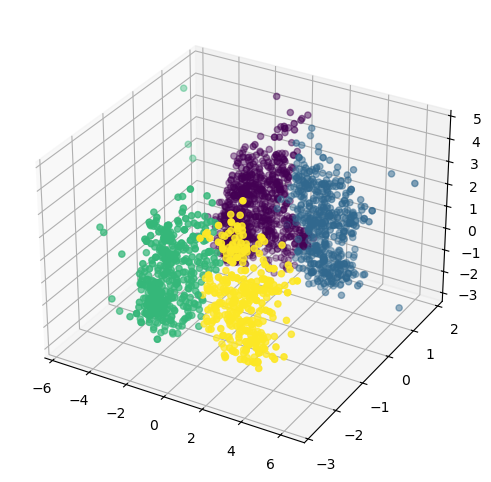

In [118]:
fig = plt.figure(figsize =(8,6))
ax = fig.add_subplot(111, projection ="3d")
ax.scatter(X_pca[:,0] , X_pca[: ,1] , X_pca[:,2] , c= agglo_labels1)